<a href="https://colab.research.google.com/github/jeankonan748/Project_Perso/blob/main/nlp_regex_pratique_bda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exercice Pratique d'expressions regulières

Avant d'écrire une regex, il faut toujours bien formulé ce qu'on recherche.
Cela aidera à construire aisément la regex résolvant le problème ciblé

In [ ]:
import re

## Validation et Extraction de formats (emails/téléphone/mot de passe)

**Format (pattern) d'un email** : username@domaine.extension

    - username: lettres, chiffres, .-_
    - domaine: lettres, chiffres, -
    - extension: 2-6 lettres

In [ ]:
emails_test = [
    "contact@example.ci",      # Valide
    "user.name@startup.co.ci", # Invalide
    "user-name@startup-co.ci", # Valide
    'ik34@uvci.edu.ci',
    "invalid@",                # Invalide
    "@invalid.com",            # Invalide
    "no-at-sign.com",          # Invalide
    "user@domain",             # Invalide (pas d'extension)
    "user name@domain.com"     # Invalide (espace)
]

In [ ]:
regex_email = r'^[\w.-]+@[a-zA-Z0-9-.]+\.[a-z]{2,6}$'
for email in emails_test:
  print(re.findall(regex_email, email))

['contact@example.ci']
['user.name@startup.co.ci']
['user-name@startup-co.ci']
['ik34@uvci.edu.ci']
[]
[]
[]
[]
[]


In [ ]:
for email in emails_test:
  if re.match(regex_email, email):
    print(email, ':', 'Email valide')
  else:
    print(email, ':', '!!! Email Invalide !!!')

contact@example.ci : Email valide
user.name@startup.co.ci : Email valide
user-name@startup-co.ci : Email valide
ik34@uvci.edu.ci : Email valide
invalid@ : !!! Email Invalide !!!
@invalid.com : !!! Email Invalide !!!
no-at-sign.com : !!! Email Invalide !!!
user@domain : !!! Email Invalide !!!
user name@domain.com : !!! Email Invalide !!!


**Formats valides de numéro de téléphone en Côte d'Ivoire**:

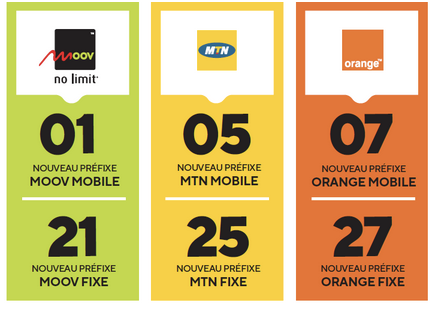

    - +225 XX XX XX XX XX
    - +225 XXXX  XXXXX X
    - 00225 XXXXXXXXXX
    - (00225) XXXXXXXXXX
    - 225 XXXXXXXXXX

In [ ]:
numeros_test = [
    "+225 07 08 09 10 11",     # Valide
    "+22507 08 09 10 11",      # Valide
    "(225)01 08 09 10 11",      # Valide
    "(00225)07 08 09 10 11",      # Valide
    "00225 05 08 09 10 11",      # Valide
    "+22507 08 09 10 11",      # Valide
    "07 08 09 10 11",          # Valide
    "07080    9101    1",              # Valide
    "01080 9101 1",              # Valide
    "05 08 0910 11",              # Valide
    "25 30 40   50",             # Invalide (trop court)
    "(+225) 7 8 9 10 11",        # InValide
    "1234567890"               # Invalide (ne commence pas par 0 ou 2)
]

In [ ]:
regex_indic = r'\(?(?:\+|0{2})?225\)?'
regex_numero = r'[02][157](?:\s*\d\s*){8}'
regex_phone = rf'(?:{regex_indic})?\s*{regex_numero}'
for numero in numeros_test:
  print(re.findall(regex_phone, numero))

['+225 07 08 09 10 11']
['+22507 08 09 10 11']
['(225)01 08 09 10 11']
['(00225)07 08 09 10 11']
['00225 05 08 09 10 11']
['+22507 08 09 10 11']
['07 08 09 10 11']
['07080    9101    1']
['01080 9101 1']
['05 08 0910 11']
[]
[]
[]


In [ ]:
for numero in numeros_test:
  if re.match(regex_phone, numero):
    print(numero, ':', 'Numéro Ivoirien valide')
  else:
    print(numero, ':', '!!! Numéro Ivoirien Invalide !!!')

+225 07 08 09 10 11 : Numéro Ivoirien valide
+22507 08 09 10 11 : Numéro Ivoirien valide
(225)01 08 09 10 11 : Numéro Ivoirien valide
(00225)07 08 09 10 11 : Numéro Ivoirien valide
00225 05 08 09 10 11 : Numéro Ivoirien valide
+22507 08 09 10 11 : Numéro Ivoirien valide
07 08 09 10 11 : Numéro Ivoirien valide
07080    9101    1 : Numéro Ivoirien valide
01080 9101 1 : Numéro Ivoirien valide
05 08 0910 11 : Numéro Ivoirien valide
25 30 40   50 : !!! Numéro Ivoirien Invalide !!!
(+225) 7 8 9 10 11 : !!! Numéro Ivoirien Invalide !!!
1234567890 : !!! Numéro Ivoirien Invalide !!!


**Mot de passe sécurisé**: 8 caractères au minimum sans espace

    - 1 lettre en majuscule
    - 1 lettre en minuscule
    - 1 chiffre
    - 1 caractère spécial (non alphanumérique)

In [ ]:
mot2pass_test = [
    '1234567',                # Non Valide
    '0987653@tB',             # Valide
    'Ra7!xmpl',               # Valide
		'Tg4#Meni',               # Valide
		'Tg4Menifjhj',            # Non Valide
		'Tg4#2w',                 # Non Valide
		'Lu@v2Xpo',               # Valide
    '1234567agtd',                # Non Valide
    'PASDENOMBRE'             # Non Valide
]

In [ ]:
majus = r'(?=\S*[A-Z]\S*)' # (?=)
minus = r'(?=\S*[a-z]\S*)'
chiffre = r'(?=\S*\d\S*)'
special = r'(?=\S*[^a-zA-Z0-9]\S*)'
nbre_caract =  r'(?=\S{8,})'
regex_mdp = rf'{majus}{minus}{chiffre}{special}{nbre_caract}'
for mdp in mot2pass_test:
  print(re.findall(regex_mdp, mdp))

[]
['', '', '']
['']
['']
[]
[]
['']
[]
[]


In [ ]:
for mdp in mot2pass_test:
  if re.match(regex_mdp, mdp):
    print(mdp, ':', 'Mot de passe valide')
  else:
    print(mdp, ':', '!!! Mot de passe Invalide !!!')

1234567 : !!! Mot de passe Invalide !!!
0987653@tB : Mot de passe valide
Ra7!xmpl : Mot de passe valide
Tg4#Meni : Mot de passe valide
Tg4Menifjhj : !!! Mot de passe Invalide !!!
Tg4#2w : !!! Mot de passe Invalide !!!
Lu@v2Xpo : Mot de passe valide
1234567agtd : !!! Mot de passe Invalide !!!
PASDENOMBRE : !!! Mot de passe Invalide !!!


## Extraction de date et de montants

In [ ]:
date_montant_test = """
Facture du 25/10/2025

Articles:
- Formation NLP:     500,000 FCFA
- Consultation IA:   300000 CFA
- Support technique: 105.500 FCFA
- Goissou:           50 000 fcfa

Total: 955,500 FCFA
Date limite de paiement: 30/10/2025
"""

In [ ]:
# Ecrire votre code pour extraire les dates et les montants

## Extraction d'information d'un Tweet

In [ ]:
tweet1 = \
"""
#société | riposte anti-covid-19 et renforcement de la liaison électrique taabo-kossou-bouaké :
plus de 177 milliards de fcfa de la jica à la côte d’ivoire\n\nen savoir plus ??
https://t.co/vbg9iaxmgk \n\n#cicg #gouvci \n#conseildesministresci https://t.co/eb1y04cmxj
"""

In [ ]:
# Ecrire une regex pour extraire les mentions #hashtags comme: #société, #cicg, etc...

In [ ]:
# Ecrire une regex pour extraire les urls: https://t.co/vbg9iaxmgk ,  https://t.co/eb1y04cmxj

In [ ]:
# Ecrire une regex pour extraire le message du tweet sans les hashtags et les urls:
# riposte anti-covid-19 et renforcement de la liaison électrique taabo-kossou-bouaké :
# plus de 177 milliards de fcfa de la jica à la côte d’ivoire
# en savoir plus

In [ ]:
tweet2 = """
#vaccinéprotégé | les vaccins réduisent de 90% la survenue de formes graves de la covid-19.

 ??????????????-???????? ???????????????? !

les sites de vaccination ??https://t.co/408zxdhs79

#cicg #gouvci
#vaccinéprotégé
#stopcovid19 #covid19
@santeci https://t.co/wxse94ah8h
"""

In [ ]:
# Appliquer les mêmes regex précédentes sur tweet2
# Trouvez-vous les résultats attendus ?
# Sinon, quelles sont les raisons? Comment pouvez corriger afin cela
# fonctionne pour tweet1 et tweet2

## Tokenisation ou division de texte en unités spécifiques

In [ ]:
text = \
"""
En Python, les expressions régulières (regex) sont gérées par le module `re`,
qui permet de trouver, d'extraire ou de remplacer des motifs de texte.
Elles sont utiles pour des tâches comme la validation de mots de passe
ou la recherche de motifs spécifiques dans des chaînes.
Mais aussi, elles servent à faire du scraping de texte.
Pour les utiliser, il faut d'abord importer le module `re`,
puis employer des fonctions comme `re.search()` pour trouver une occurrence,
`re.findall()` pour trouver toutes les occurrences,
ou `re.sub()` pour remplacer les motifs.
"""
text

In [ ]:
# Décomposer tout le texte en mots en utilisant les regex.
# Utiliser d'abord les espaces, ponctuation comme séparateur de mots
# puis traitez les apostrophes: "d'extraire" --> "d'", "extraire"